# Titanic Survival — Exploratory Data Analysis

**Goal:** Understand the data deeply before making any modelling decisions.  
Each section ends with a *Key Finding* that directly informs a feature-engineering or preprocessing choice.

In [187]:
import os, zipfile, pathlib, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, pointbiserialr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Data Acquisition

In [ ]:
DATA_DIR  = pathlib.Path('..') / 'data'
TRAIN_CSV = DATA_DIR / 'train.csv'
DATA_DIR.mkdir(exist_ok=True)

if not TRAIN_CSV.exists():
    try:
        import kaggle
        kaggle.api.authenticate()
        kaggle.api.competition_download_file('titanic', 'train.csv', path=DATA_DIR)
        zip_path = DATA_DIR / 'train.csv.zip'
        if zip_path.exists():
            with zipfile.ZipFile(zip_path, 'r') as z:
                z.extractall(DATA_DIR)
            zip_path.unlink()
        print('✓ Downloaded train.csv from Kaggle API.')
    except Exception as e:
        print(f'Kaggle unavailable ({e}) — falling back to GitHub mirror.')
        import urllib.request
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv',
            TRAIN_CSV
        )
        print('✓ Downloaded from GitHub mirror.')
else:
    print(f'✓ Using cached {TRAIN_CSV}')

df = pd.read_csv(TRAIN_CSV)
print(f'\nDataset saved at: {TRAIN_CSV.resolve()}')
print(f'Shape: {df.shape}  ({df.shape[0]} passengers, {df.shape[1]} columns)')
df.head()

## 2. Dataset Overview

In [189]:
summary = pd.DataFrame({
    'dtype':   df.dtypes,
    'missing': df.isnull().sum(),
    'missing%': (df.isnull().mean() * 100).round(1),
    'unique':  df.nunique(),
    'sample':  df.iloc[0]
})
summary

,dtype,missing,missing%,unique,sample
PassengerId,int64,0,0.000,891,1
Survived,int64,0,0.000,2,0
Pclass,int64,0,0.000,3,3
Name,object,0,0.000,891,"Braund, Mr. Owen Harris"
Sex,object,0,0.000,2,male
Age,float64,177,19.900,88,22.000
SibSp,int64,0,0.000,7,1
Parch,int64,0,0.000,7,0
Ticket,object,0,0.000,681,A/5 21171
Fare,float64,0,0.000,248,7.250


In [190]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000,891.000,891.000,714.000,891.000,891.000,891.000
mean,446.000,0.384,2.309,29.699,0.523,0.382,32.204
std,257.354,0.487,0.836,14.526,1.103,0.806,49.693
min,1.000,0.000,1.000,0.420,0.000,0.000,0.000
25%,223.500,0.000,2.000,20.125,0.000,0.000,7.910
50%,446.000,0.000,3.000,28.000,0.000,0.000,14.454
75%,668.500,1.000,3.000,38.000,1.000,0.000,31.000
max,891.000,1.000,3.000,80.000,8.000,6.000,512.329


## 3. Missing Values

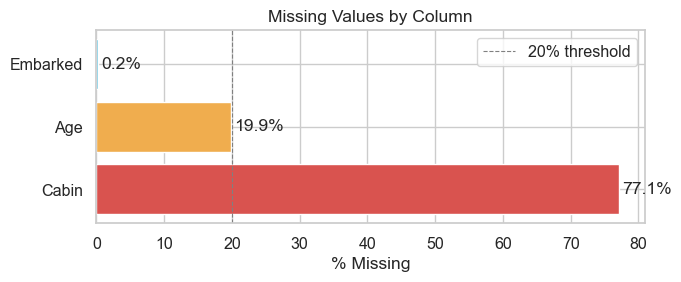

In [191]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=['#d9534f' if v > 50 else '#f0ad4e' if v > 10 else '#5bc0de'
                      for v in missing_pct.values])
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column')
ax.axvline(20, ls='--', color='gray', lw=0.8, label='20% threshold')
for bar, v in zip(bars, missing_pct.values):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center')
ax.legend()
plt.tight_layout()
plt.show()

**Key Finding:**  
- `Cabin` (77% missing) → extract binary `has_cabin` flag; missingness itself is informative (mostly 3rd class).  
- `Age` (20% missing) → impute per-Title median — `Master` (young boys) gets a different median than `Mr` (adult men), so a single global median would distort both groups.  
- `Embarked` (2 passengers missing, 0.2%) → fill with `S` (Southampton), the most common port. Two rows — no strategy needed beyond mode.

## 4. Target Distribution

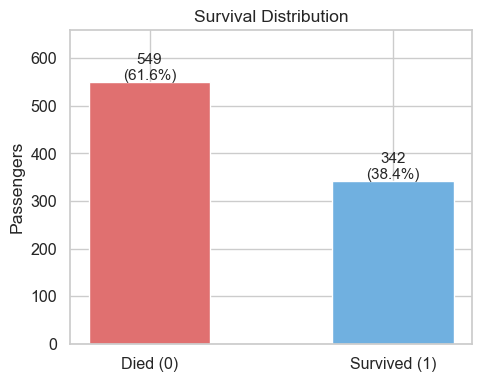

Class ratio (died:survived) = 1.61:1 — mild imbalance.
→ Use F1 and ROC-AUC as primary metrics, not raw accuracy.


In [192]:
counts = df['Survived'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Died (0)', 'Survived (1)'], counts.values, color=['#e07070', '#70b0e0'], width=0.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Survival Distribution')
ax.set_ylabel('Passengers')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

imbalance = counts[0] / counts[1]
print(f'Class ratio (died:survived) = {imbalance:.2f}:1 — mild imbalance.')
print('→ Use F1 and ROC-AUC as primary metrics, not raw accuracy.')

## 5. Survival by Individual Features

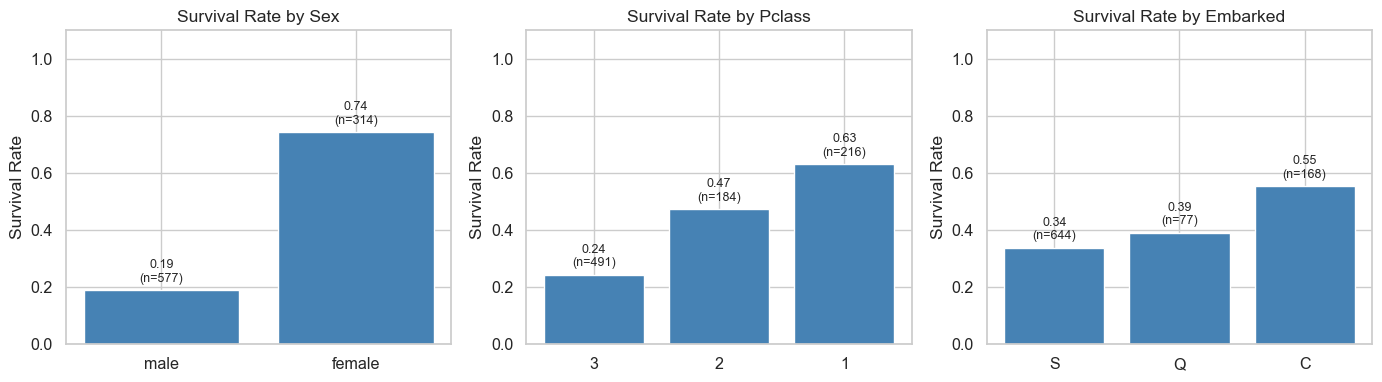

In [193]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['Sex', 'Pclass', 'Embarked']):
    rate  = df.groupby(col)['Survived'].mean().sort_values()
    n     = df.groupby(col)['Survived'].count()
    bars  = ax.bar(rate.index.astype(str), rate.values, color='steelblue')
    ax.set_title(f'Survival Rate by {col}')
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1.1)
    for bar, (label, val) in zip(bars, rate.items()):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.03,
                f'{val:.2f}\n(n={n[label]})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Pclass × Sex Interaction (Are They Independent?)

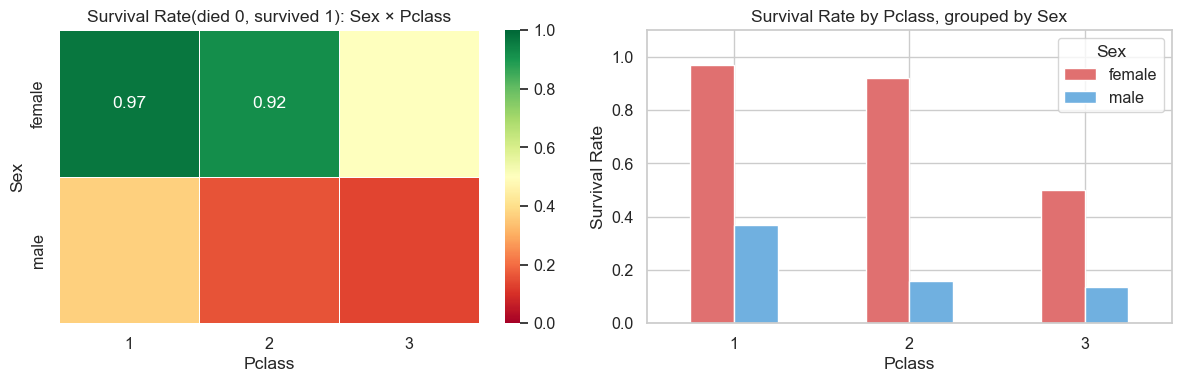

Pclass     1     2     3
Sex                     
female 0.968 0.921 0.500
male   0.369 0.157 0.135


In [194]:
pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Survival Rate(died 0, survived 1): Sex × Pclass')

# Grouped bar
pivot.T.plot(kind='bar', ax=axes[1], rot=0, color=['#e07070', '#70b0e0'])
axes[1].set_title('Survival Rate by Pclass, grouped by Sex')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1.1)
axes[1].legend(title='Sex')

plt.tight_layout()
plt.show()

print(pivot.round(3))

**Key Finding:**  
Sex and Pclass interact — a 3rd-class woman survived at ~50%, far below a 1st-class woman (~97%) but still above a 3rd-class man (~14%).  
These features are NOT independent; the model needs to capture this interaction.

## 7. Age Analysis

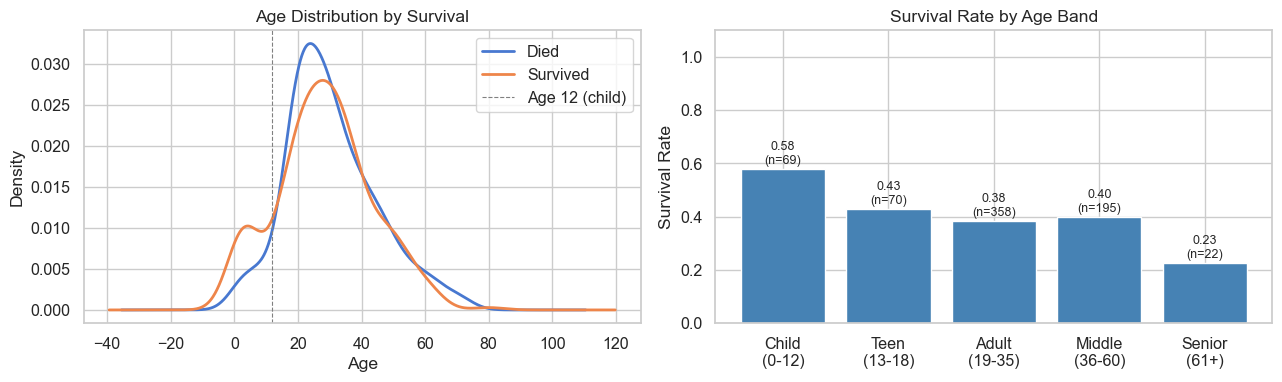

t-test: t=2.067, p=0.0391
Cohen's d = 0.157  (small effect)
Mean age — Died: 30.6  |  Survived: 28.3


In [195]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KDE by survival
for label, grp in df.groupby('Survived'):
    grp['Age'].dropna().plot(kind='kde', ax=axes[0], label=['Died', 'Survived'][label], lw=2)
axes[0].axvline(12, ls='--', color='gray', lw=0.8, label='Age 12 (child)')
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].legend()

# Survival rate by age band
df['AgeBand'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                        labels=['Child\n(0-12)', 'Teen\n(13-18)', 'Adult\n(19-35)',
                                'Middle\n(36-60)', 'Senior\n(61+)'])
band_rate = df.groupby('AgeBand', observed=True)['Survived'].mean()
band_n    = df.groupby('AgeBand', observed=True)['Survived'].count()
bars = axes[1].bar(band_rate.index.astype(str), band_rate.values, color='steelblue')
for bar, (label, val) in zip(bars, band_rate.items()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.2f}\n(n={band_n[label]})', ha='center', fontsize=9)
axes[1].set_title('Survival Rate by Age Band')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# t-test + effect size
died = df[df['Survived'] == 0]['Age'].dropna()
surv = df[df['Survived'] == 1]['Age'].dropna()
t, p = ttest_ind(died, surv)
cohens_d = (died.mean() - surv.mean()) / np.sqrt((died.std()**2 + surv.std()**2) / 2)
print(f't-test: t={t:.3f}, p={p:.4f}')
print(f"Cohen's d = {cohens_d:.3f}  ({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'} effect)")
print(f'Mean age — Died: {died.mean():.1f}  |  Survived: {surv.mean():.1f}')

### 7a. Smarter Age Imputation — by Title Group

In [196]:
# Step 1 — see every title raw, before any merging
df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.')[0].str.strip()

raw_counts = df['Title'].value_counts()
print(f'Total unique titles: {len(raw_counts)}\n')
print(raw_counts.to_string())

Total unique titles: 17

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1


Title counts after merging:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Age statistics by Title:
        median   mean  count    std
Title                              
Master   3.500  4.600     36  3.600
Miss    21.000 21.800    149 12.900
Mr      30.000 32.400    398 12.700
Mrs     35.000 35.800    109 11.400
Rare    48.500 45.500     22 11.800


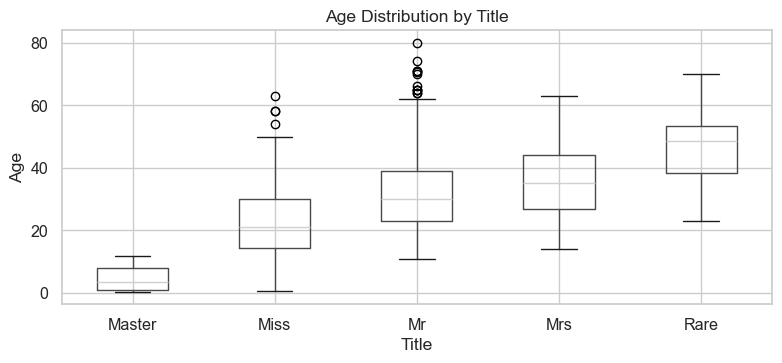


→ Imputing Age with per-Title median avoids pushing Master (boys) to the adult median.


In [197]:
# Ensure Title exists (safe to run even if previous cell was skipped)
if 'Title' not in df.columns:
    df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.')[0].str.strip()

# Step 1 — normalise French/equivalent titles to their English counterpart
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss'})

# Step 2 — keep only the 4 titles with enough data to be statistically meaningful;
#           everything else → Rare (Dr=7, Rev=6, Col=2, Major=2, singletons — all too few)
KEEP_TITLES = {'Mr', 'Miss', 'Mrs', 'Master'}
df['Title'] = df['Title'].apply(lambda t: t if t in KEEP_TITLES else 'Rare')

print('Title counts after merging:')
print(df['Title'].value_counts())

title_age = df.groupby('Title')['Age'].agg(['median', 'mean', 'count', 'std'])
print('\nAge statistics by Title:')
print(title_age.round(1))

fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='Age', by='Title', ax=ax)
ax.set_title('Age Distribution by Title')
ax.set_xlabel('Title')
ax.set_ylabel('Age')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('\n→ Imputing Age with per-Title median avoids pushing Master (boys) to the adult median.')

## 8. Title — Signal Strength

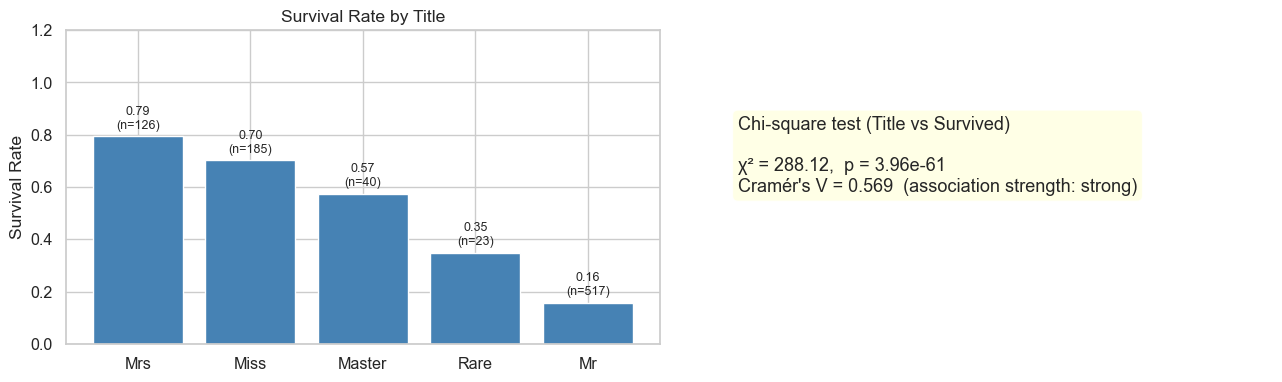

In [198]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Survival rate by title
title_surv = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
title_n    = df.groupby('Title')['Survived'].count()
bars = axes[0].bar(title_surv.index, title_surv.values, color='steelblue')
for bar, (label, val) in zip(bars, title_surv.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.03,
                 f'{val:.2f}\n(n={title_n[label]})', ha='center', fontsize=9)
axes[0].set_title('Survival Rate by Title')
axes[0].set_ylim(0, 1.2)
axes[0].set_ylabel('Survival Rate')

# Chi-square
ct = pd.crosstab(df['Title'], df['Survived'])
chi2, p, dof, _ = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))
axes[1].axis('off')
axes[1].text(0.1, 0.6, f'Chi-square test (Title vs Survived)\n\n'
             f'χ² = {chi2:.2f},  p = {p:.2e}\n'
             f"Cramér's V = {cramers_v:.3f}  (association strength: "
             f"{'weak' if cramers_v<0.1 else 'moderate' if cramers_v<0.3 else 'strong'})",
             fontsize=13, va='center', transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

## 9. Family Size — Is the Relationship Linear?

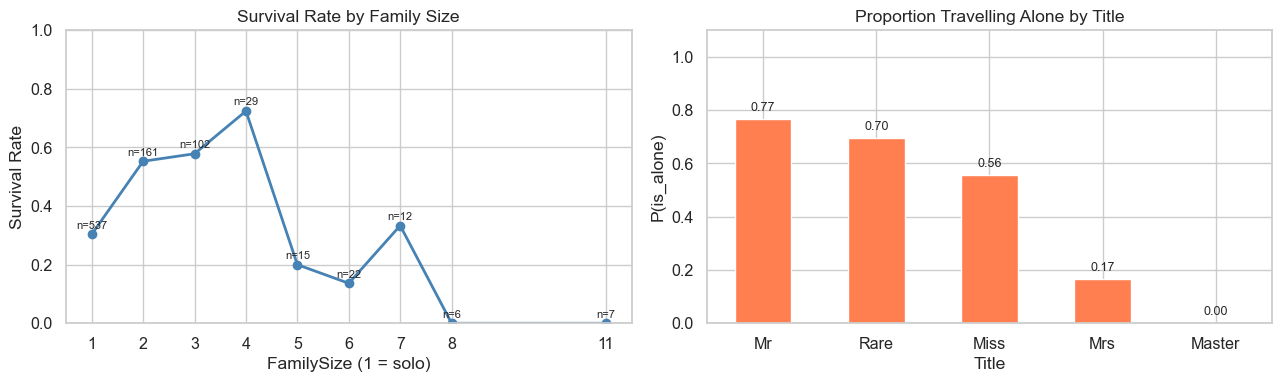

Median FamilySize by Title:
Title
Master   4.000
Miss     1.000
Mr       1.000
Mrs      2.000
Rare     1.000
Name: FamilySize, dtype: float64


In [199]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['is_alone']   = (df['FamilySize'] == 1).astype(int)

family_surv = df.groupby('FamilySize')['Survived'].agg(['mean', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Survival rate curve
axes[0].plot(family_surv.index, family_surv['mean'], marker='o', color='steelblue', lw=2)
for x, row in family_surv.iterrows():
    axes[0].text(x, row['mean'] + 0.02, f'n={int(row["count"])}', ha='center', fontsize=8)
axes[0].set_title('Survival Rate by Family Size')
axes[0].set_xlabel('FamilySize (1 = solo)')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(family_surv.index)

# Title overlap: does Title predict is_alone?
alone_by_title = df.groupby('Title')['is_alone'].mean().sort_values(ascending=False)
alone_by_title.plot(kind='bar', ax=axes[1], color='coral', rot=0)
axes[1].set_title('Proportion Travelling Alone by Title')
axes[1].set_ylabel('P(is_alone)')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(alone_by_title.values):
    axes[1].text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Median FamilySize by Title:')
print(df.groupby('Title')['FamilySize'].median())

**Key Finding:**  
- FamilySize has a **non-linear** effect: solo travellers and large families (7+) survived less; mid-size (2–4) survived most.  
- `is_alone` is partially redundant with `Title` (Mr have high alone-rate; Master/Mrs lower), but FamilySize carries additional signal beyond the binary.  
- **Decision:** keep `FamilySize`; drop `is_alone` (captured by FamilySize + Title).

## 10. Fare — Raw vs Per-Person

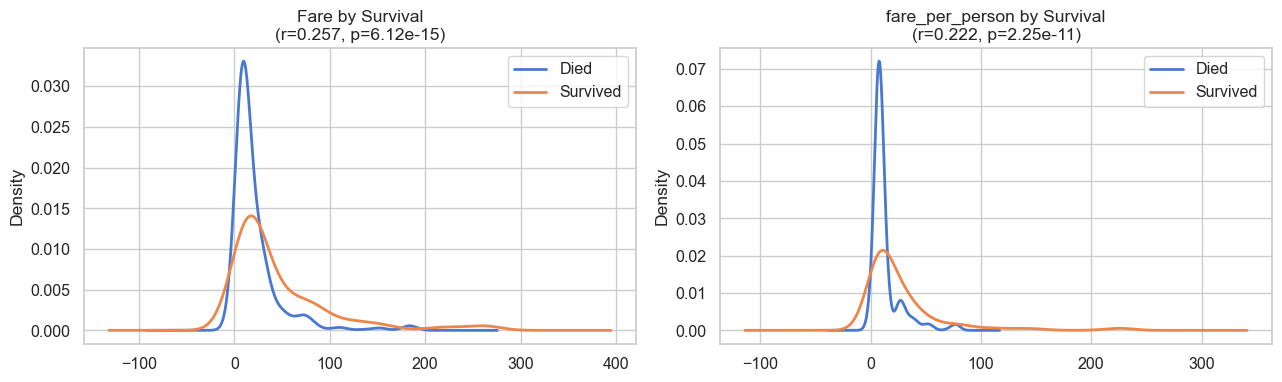

Pearson r — Fare vs Survived:            0.257
Pearson r — fare_per_person vs Survived: 0.222
Correlation between the two:             0.841


In [200]:
df['fare_per_person'] = df['Fare'] / df['FamilySize']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['Fare', 'fare_per_person']):
    for label, grp in df.groupby('Survived'):
        grp[col].clip(upper=grp[col].quantile(0.99)).plot(
            kind='kde', ax=ax, label=['Died', 'Survived'][label], lw=2)
    r, p = pointbiserialr(df['Survived'], df[col].fillna(0))
    ax.set_title(f'{col} by Survival\n(r={r:.3f}, p={p:.2e})')
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Pearson r — Fare vs Survived:            {df['Fare'].corr(df['Survived']):.3f}")
print(f"Pearson r — fare_per_person vs Survived: {df['fare_per_person'].corr(df['Survived']):.3f}")
print(f"Correlation between the two:             {df['Fare'].corr(df['fare_per_person']):.3f}")

## 11. Cabin — Deck Extraction

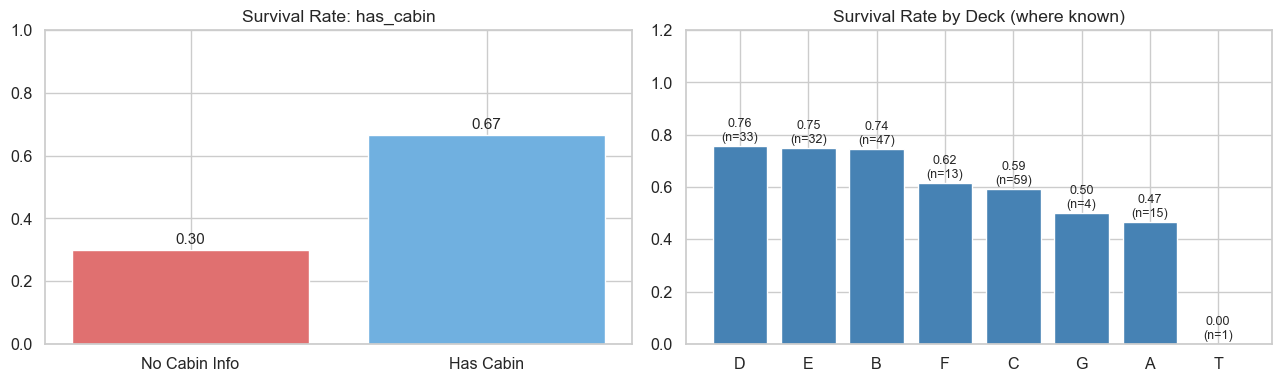

Cabin known for 22.9% of passengers.
→ Too sparse for Deck as a feature; use has_cabin binary flag instead.


In [201]:
df['has_cabin'] = df['Cabin'].notna().astype(int)
df['Deck']      = df['Cabin'].str[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# has_cabin vs survival
cabin_rate = df.groupby('has_cabin')['Survived'].mean()
axes[0].bar(['No Cabin Info', 'Has Cabin'], cabin_rate.values, color=['#e07070', '#70b0e0'])
for i, v in enumerate(cabin_rate.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)
axes[0].set_title('Survival Rate: has_cabin')
axes[0].set_ylim(0, 1)

# Deck vs survival (where known)
deck_rate = df.dropna(subset=['Deck']).groupby('Deck')['Survived'].mean().sort_values(ascending=False)
deck_n    = df.dropna(subset=['Deck']).groupby('Deck')['Survived'].count()
bars = axes[1].bar(deck_rate.index, deck_rate.values, color='steelblue')
for bar, (label, val) in zip(bars, deck_rate.items()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.2f}\n(n={deck_n[label]})', ha='center', fontsize=9)
axes[1].set_title('Survival Rate by Deck (where known)')
axes[1].set_ylim(0, 1.2)

plt.tight_layout()
plt.show()

print(f'Cabin known for {df["has_cabin"].mean()*100:.1f}% of passengers.')
print('→ Too sparse for Deck as a feature; use has_cabin binary flag instead.')

## 12. Correlation & Redundancy Check

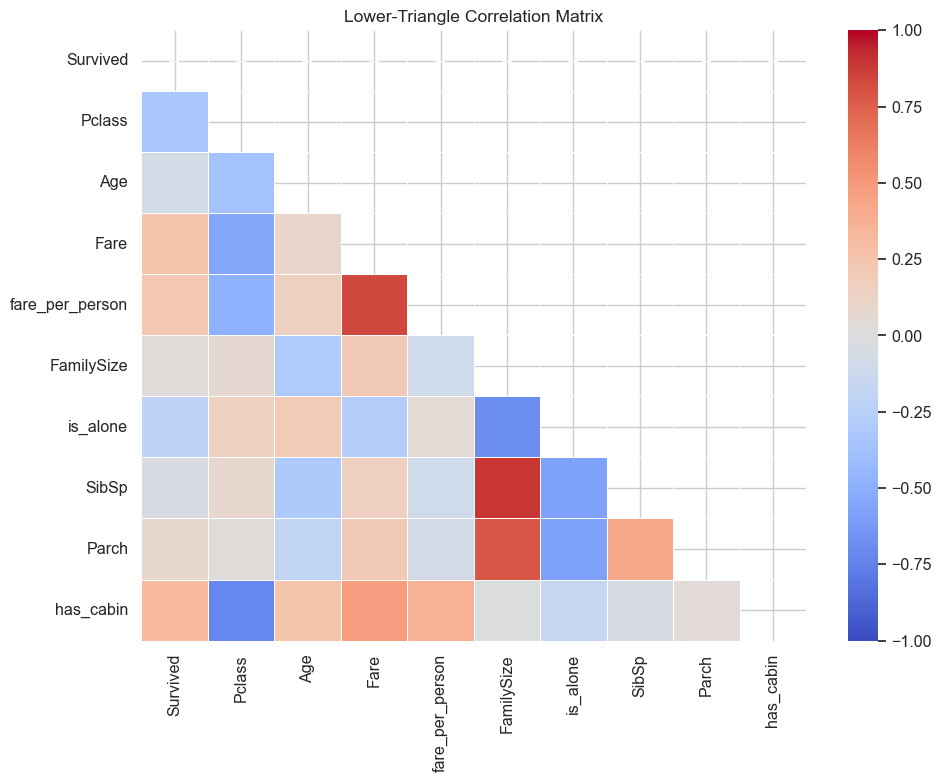

Feature pairs with |r| > 0.7 (potential redundancy):
  fare_per_person      <-> Fare                  r=0.841
  SibSp                <-> FamilySize            r=0.891
  Parch                <-> FamilySize            r=0.783
  has_cabin            <-> Pclass                r=-0.726


In [202]:
num_cols = ['Survived', 'Pclass', 'Age', 'Fare', 'fare_per_person',
            'FamilySize', 'is_alone', 'SibSp', 'Parch', 'has_cabin']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Lower-Triangle Correlation Matrix')
plt.tight_layout()
plt.show()

# Flag high correlations
print('Feature pairs with |r| > 0.7 (potential redundancy):')
for i in range(len(corr.columns)):
    for j in range(i):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {corr.columns[i]:20s} <-> {corr.columns[j]:20s}  r={r:.3f}')

## 13. Statistical Tests — All Features vs Survived

Two separate tests are used depending on the feature type:

- **Categorical features → Chi-square + Cramér's V**: tests whether survival rates differ across categories. V ranges 0–1 (strength of association).
- **Numerical features → Point-biserial r**: measures the *linear* correlation with Survived. Important caveat: a feature with a non-linear relationship (like FamilySize, which goes up then down) will score near zero here even if the pattern is real.

**These tests inform — they do not make the feature decision.** A feature can be statistically significant but redundant (Sex, absorbed by Title), or statistically insignificant but carry a real non-linear pattern (FamilySize).

In [203]:
# --- Categorical features: Chi-square + Cramér's V ---
print('CATEGORICAL FEATURES (Chi-square + Cramér\'s V)')
print('Cramér\'s V: 0.1=weak, 0.3=moderate, 0.5+=strong\n')
cat_header = f"{'Feature':<12} {'chi2':>8} {'p-value':>10} {'V':>8}  Association"
print(cat_header)
print('-' * len(cat_header))
for col in ['Sex', 'Pclass', 'Embarked', 'Title']:
    ct = pd.crosstab(df[col], df['Survived'])
    chi2, p, _, _ = chi2_contingency(ct)
    v = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))
    strength = 'weak' if v < 0.1 else 'moderate' if v < 0.3 else 'strong'
    print(f'{col:<12} {chi2:>8.2f} {p:>10.4f} {v:>8.3f}  {strength}')

print()

# --- Numerical features: Point-biserial r (LINEAR association only) ---
print('NUMERICAL FEATURES (Point-biserial r — linear association only)')
print('Note: r≈0 does NOT mean no effect — it means no LINEAR effect.\n')
num_header = f"{'Feature':<20} {'r':>8} {'p-value':>10}  Linear signal?"
print(num_header)
print('-' * len(num_header))
for col in ['Age', 'Fare', 'fare_per_person', 'FamilySize']:
    r, p = pointbiserialr(df['Survived'], df[col].fillna(df[col].median()))
    linear = 'yes' if p < 0.05 else 'no (may still have non-linear effect)'
    print(f'{col:<20} {r:>8.3f} {p:>10.4f}  {linear}')

CATEGORICAL FEATURES (Chi-square + Cramér's V)
Cramér's V: 0.1=weak, 0.3=moderate, 0.5+=strong

Feature          chi2    p-value        V  Association
------------------------------------------------------
Sex            260.72     0.0000    0.541  strong
Pclass         102.89     0.0000    0.340  strong
Embarked        26.49     0.0000    0.172  moderate
Title          288.12     0.0000    0.569  strong

NUMERICAL FEATURES (Point-biserial r — linear association only)
Note: r≈0 does NOT mean no effect — it means no LINEAR effect.

Feature                     r    p-value  Linear signal?
--------------------------------------------------------
Age                    -0.065     0.0528  no (may still have non-linear effect)
Fare                    0.257     0.0000  yes
fare_per_person         0.222     0.0000  yes
FamilySize              0.017     0.6199  no (may still have non-linear effect)


## 14. Feature Decision Summary

In [204]:
decision = pd.DataFrame([
    ('Pclass',          'KEEP',  'Strong linear signal (r=-0.338); survival drops clearly with class'),
    ('Title',           'KEEP',  'Strongest feature (V=0.569); encodes sex + age + social status'),
    ('Age',             'KEEP',  'Borderline (p=0.053, small effect); kept for per-Title imputation value'),
    ('fare_per_person', 'KEEP',  'Significant (r=0.222); normalises group-ticket inflation vs raw Fare'),
    ('FamilySize',      'KEEP',  'r≈0 because survival goes up then down (inverted-U) — the positive and negative halves cancel in a linear test. The non-linear pattern is real and visible in the survival curve.'),
    ('has_cabin',       'KEEP',  'Correlated with Pclass (r=-0.726) but captures additional location signal'),
    ('Embarked',        'KEEP',  'Significant (V=0.172); moderate signal reflecting class mix per port'),
    ('Sex',             'DROP',  'Fully absorbed by Title (Miss/Mrs vs Mr/Master)'),
    ('is_alone',        'DROP',  'Redundant given FamilySize + Title'),
    ('Fare (raw)',      'DROP',  'Replaced by fare_per_person; highly correlated (r=0.841)'),
    ('SibSp / Parch',   'DROP',  'Replaced by FamilySize; both correlate >0.78 with it'),
    ('Deck',            'DROP',  '77% missing — too sparse; has_cabin used instead'),
    ('PassengerId',     'DROP',  'Pure index, no signal'),
    ('Name / Ticket',   'DROP',  'Used only to extract Title; raw text discarded'),
], columns=['Feature', 'Decision', 'Reason'])

keep = decision[decision['Decision'] == 'KEEP']
drop = decision[decision['Decision'] == 'DROP']

print('=== FINAL FEATURE SET ===')
print(keep[['Feature', 'Reason']].to_string(index=False))
print('\n=== DROPPED ===')
print(drop[['Feature', 'Reason']].to_string(index=False))

=== FINAL FEATURE SET ===
        Feature                                                                                                                                                                            Reason
         Pclass                                                                                                                Strong linear signal (r=-0.338); survival drops clearly with class
          Title                                                                                                                    Strongest feature (V=0.569); encodes sex + age + social status
            Age                                                                                                           Borderline (p=0.053, small effect); kept for per-Title imputation value
fare_per_person                                                                                                              Significant (r=0.222); normalises group-ticket inflation vs raw Fare
    

## 15. Preprocessing Preview

Runs the actual pipeline from `src/preprocess.py` to confirm every decision above produces a clean, model-ready feature matrix.

In [ ]:
import sys
sys.path.append(str(pathlib.Path('..') / 'src'))

from sklearn.model_selection import train_test_split
from preprocess import fit_transform, transform, FEATURES

df_raw   = pd.read_csv(TRAIN_CSV)
train_df, val_df = train_test_split(df_raw, test_size=0.2, random_state=42, stratify=df_raw['Survived'])

print(f'Train: {len(train_df)} rows  |  Val: {len(val_df)} rows')
print(f'\nBEFORE — raw columns ({len(df_raw.columns)}): {list(df_raw.columns)}')
print(f'Missing:  Age={df_raw["Age"].isnull().sum()}  Cabin={df_raw["Cabin"].isnull().sum()}  Embarked={df_raw["Embarked"].isnull().sum()}')

X_train, y_train, params = fit_transform(train_df)
X_val                     = transform(val_df, params)
y_val                     = val_df['Survived'].values

print(f'\nAFTER — feature matrix: {X_train.shape[0]} rows × {X_train.shape[1]} features')
print(f'Features: {FEATURES}')
print(f'\nMissing in X_train: {pd.DataFrame(X_train, columns=FEATURES).isnull().sum().sum()}')
print(f'Missing in X_val:   {pd.DataFrame(X_val,   columns=FEATURES).isnull().sum().sum()}')

pd.DataFrame(X_train[:5], columns=FEATURES).round(3)

## 16. Model Generalisation — "Women and Children First"

The model learned its survival rules from the Titanic — a disaster where the evacuation explicitly followed the **"women and children first"** protocol. This is reflected strongly in the data:

- **Women** survived at 74% vs **men** at 19%
- **Children under 15** survived at a higher rate than adults
- **1st class passengers** had far better access to lifeboats

These patterns are not a universal law of maritime disasters — they reflect the specific social norms, crew decisions, and ship layout of the Titanic in 1912. A model trained on this data will confidently predict survival for women and death for men, even when applied to a disaster that followed different evacuation dynamics.

**This is distribution shift** — the gap between the world the model was trained on and the world it is applied to. It is one of the most common failure modes of machine learning models in production, and a key reason why model performance should always be validated on data that matches the deployment context.